# TIGeR Kaggle Workflow

This notebook executes the complete Text-Image Generative Repair (TIGeR) pipeline.

### ⚠️ Setup Instructions Before You Start:
1. **Turn on the GPU:** Go to the right sidebar -> `Notebook options` -> `Accelerator` -> select **GPU T4 x2** or **P100**.
2. **Add your Gemini API Key:** Go to the right sidebar -> `Add-ons` -> `Secrets`. Add a new secret named `GEMINI_API_KEY` and paste your key.

In [1]:
!rm -rf TIGeR-Text-Image-Generative-Repair
!git clone https://github.com/namaray/TIGeR-Text-Image-Generative-Repair.git
%cd TIGeR-Text-Image-Generative-Repair
!pip install -e ".[dev,vlm,gen]" -q

Cloning into 'TIGeR-Text-Image-Generative-Repair'...
remote: Enumerating objects: 549, done.
remote: Counting objects: 100% (549/549), done.
remote: Compressing objects: 100% (408/408), done.
remote: Total 549 (delta 148), reused 524 (delta 124), pack-reused 0 (from 0)
Receiving objects: 100% (549/549), 1.18 MiB | 7.61 MiB/s, done.
Resolving deltas: 100% (148/148), done.
/kaggle/working/TIGeR-Text-Image-Generative-Repair
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiger (pyproject.toml) ... done


In [2]:
from kaggle_secrets import UserSecretsClient
import os

try:
    user_secrets = UserSecretsClient()
    gemini_key = user_secrets.get_secret("gemini api")
    os.environ["GEMINI_API_KEY"] = gemini_key
    print("✅ Gemini API Key loaded successfully from Kaggle Secrets!")
except Exception as e:
    print("❌ Failed to load Gemini API Key. Did you add it to Kaggle Secrets? Error:", e)

✅ Gemini API Key loaded successfully from Kaggle Secrets!


## 1. Data Generation (Synthgen)

In [3]:
!python -m tiger.cli synthgen

generated 240 products -> data/sample/products.parquet
category  split      
bags      calibration    31
          report         29
hats      calibration    27
          report         33
shirts    calibration    29
          report         31
shoes     calibration    33
          report         27


## 2. Calibration & Training

In [4]:
!python -m tiger.cli calibrate

tokenizer_config.json: 100%|███████████████████| 592/592 [00:00<00:00, 1.95MB/s]
vocab.json: 862kB [00:00, 24.5MB/s]
merges.txt: 525kB [00:00, 94.4MB/s]
tokenizer.json: 2.22MB [00:00, 162MB/s]
special_tokens_map.json: 100%|█████████████████| 389/389 [00:00<00:00, 3.19MB/s]
config.json: 4.19kB [00:00, 12.9MB/s]
pytorch_model.bin: 100%|█████████████████████| 605M/605M [00:06<00:00, 91.1MB/s]
Loading weights:  68%|▋| 272/398 [00:00<00:00, 3548.15it/s, Materializing param=
Loading weights: 100%|█| 398/398 [00:00<00:00, 3272.86it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.

preprocessor_config.json: 100%|███████████

In [5]:
!python -m tiger.cli train-arbiter

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_cal_seed1007.parquet
{
  "seed": 1007,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 120,
  "rows_noisy": 34,
  "by_label": {
    "clean": 86,
    "swap_image": 16,
    "mutate_text": 15,
    "mixed": 2,
    "missing_image": 1
  },
  "by_subtype": {
    "swap_image": 12,
    "color_flip": 7,
    "swap_image_same_category": 4,
    "material_flip": 2,
    "attribute_drop": 2,
    "near_color_flip": 2,
    "title_contradiction": 2,
    "mixed_swap_color": 2,
    "missing_image": 1
  },
  "self_verified": true
}
Loading weights: 100%|█| 398/398 [00:00<00:00, 3509.83it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-base-pa

In [6]:
!python -m tiger.cli calibrate-fusion

precision floor 0.85; calibrated on 960 labelled rows
  flag_probe_color           precision=0.92 fired=137 z>=2.5
  flag_probe_material        precision=1.0 fired=8 z>=2.0
  flag_probe_pattern         precision=0.941 fired=68 z>=2.5
  flag_low_sim               precision=0.872 fired=164
  flag_text_out_of_domain    precision=1.0 fired=16
  flag_title_contradiction   precision=1.0 fired=16
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_fusion.json


## 3. The Pipeline (Detect -> Route -> Repair)

In [7]:
!python -m tiger.cli noise --seed 7

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_seed7.parquet
{
  "seed": 7,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 120,
  "rows_noisy": 34,
  "by_label": {
    "clean": 86,
    "swap_image": 16,
    "mutate_text": 15,
    "mixed": 2,
    "missing_image": 1
  },
  "by_subtype": {
    "swap_image": 12,
    "color_flip": 7,
    "swap_image_same_category": 4,
    "mixed_swap_color": 2,
    "title_contradiction": 2,
    "material_flip": 2,
    "near_color_flip": 2,
    "attribute_drop": 2,
    "missing_image": 1
  },
  "self_verified": true
}


In [8]:
!python -m tiger.cli detect --seed 7

Loading weights: 100%|█| 398/398 [00:00<00:00, 3803.80it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/sieve_seed7.parquet
flagged 39/120 rows
flag_reason
ok                     81
low_sim                19
probe_color            13
probe_pattern           2
title_contradiction     2
text_out_of_domain      2
missing_image           1


In [9]:
!python -m tiger.cli analyze --seed 7

Loading weights: 100%|█| 398/398 [00:00<00:00, 2741.29it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/evidence_seed7.jsonl (39 evidence records)


In [10]:
!python -m tiger.cli route --seed 7

error_type     CLEAN  E1  E2  E3  E4
truth_raw                           
clean              1   0   0   0   8
missing_image      0   0   0   0   1
mixed              0   0   0   1   1
mutate_text        0   9   0   0   3
swap_image         0   1   3   5   6

actions:
action
human_review                  18
v2t_patch                     10
t2v_replace_image_then_v2t     6
t2v_replace_image              3
acquire_image                  1
dismiss                        1
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/route_plan_seed7.csv


### Final Step: Closed-Loop Repair (with Gemini VLM Judge)

In [11]:
!python -m tiger.cli repair --seed 7 --vlm-judge --generative-fallback


/usr/local/lib/python3.12/dist-packages/wrapt/importer.py:223: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  self.__wrapped__.exec_module(module)
VLM judge: gemini-3.5-flash-lite (Gemini)
[GeminiVLMJudge] raw='YES' -> True
Loading weights: 100%|█| 398/398 [00:00<00:00, 3002.77it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[GeminiVLMJudge] raw='YES

## 4. Export Outputs

In [12]:
!zip -r /kaggle/working/tiger_outputs.zip data/outputs data/thresholds data/processed
print("✅ Download tiger_outputs.zip from the '/kaggle/working' directory in the right sidebar!")

  adding: data/outputs/ (stored 0%)
  adding: data/outputs/sieve_cal_seed1013_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_seed7_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_cal_seed1012_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_cal_seed1013.parquet (deflated 52%)
  adding: data/outputs/evidence_cal_seed1008.jsonl (deflated 81%)
  adding: data/outputs/sieve_cal_seed1009_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_cal_seed1010_arrays.npz (deflated 0%)
  adding: data/outputs/evidence_cal_seed1010.jsonl (deflated 81%)
  adding: data/outputs/sieve_seed7.parquet (deflated 53%)
  adding: data/outputs/sieve_cal_seed1007_arrays.npz (deflated 0%)
  adding: data/outputs/repair_report_seed7.json (deflated 89%)
  adding: data/outputs/sieve_cal_seed1011_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_cal_seed1014.parquet (deflated 52%)
  adding: data/outputs/sieve_cal_seed1012.parquet (deflated 52%)
  adding: data/outputs/sieve_cal_seed1010.parquet (def

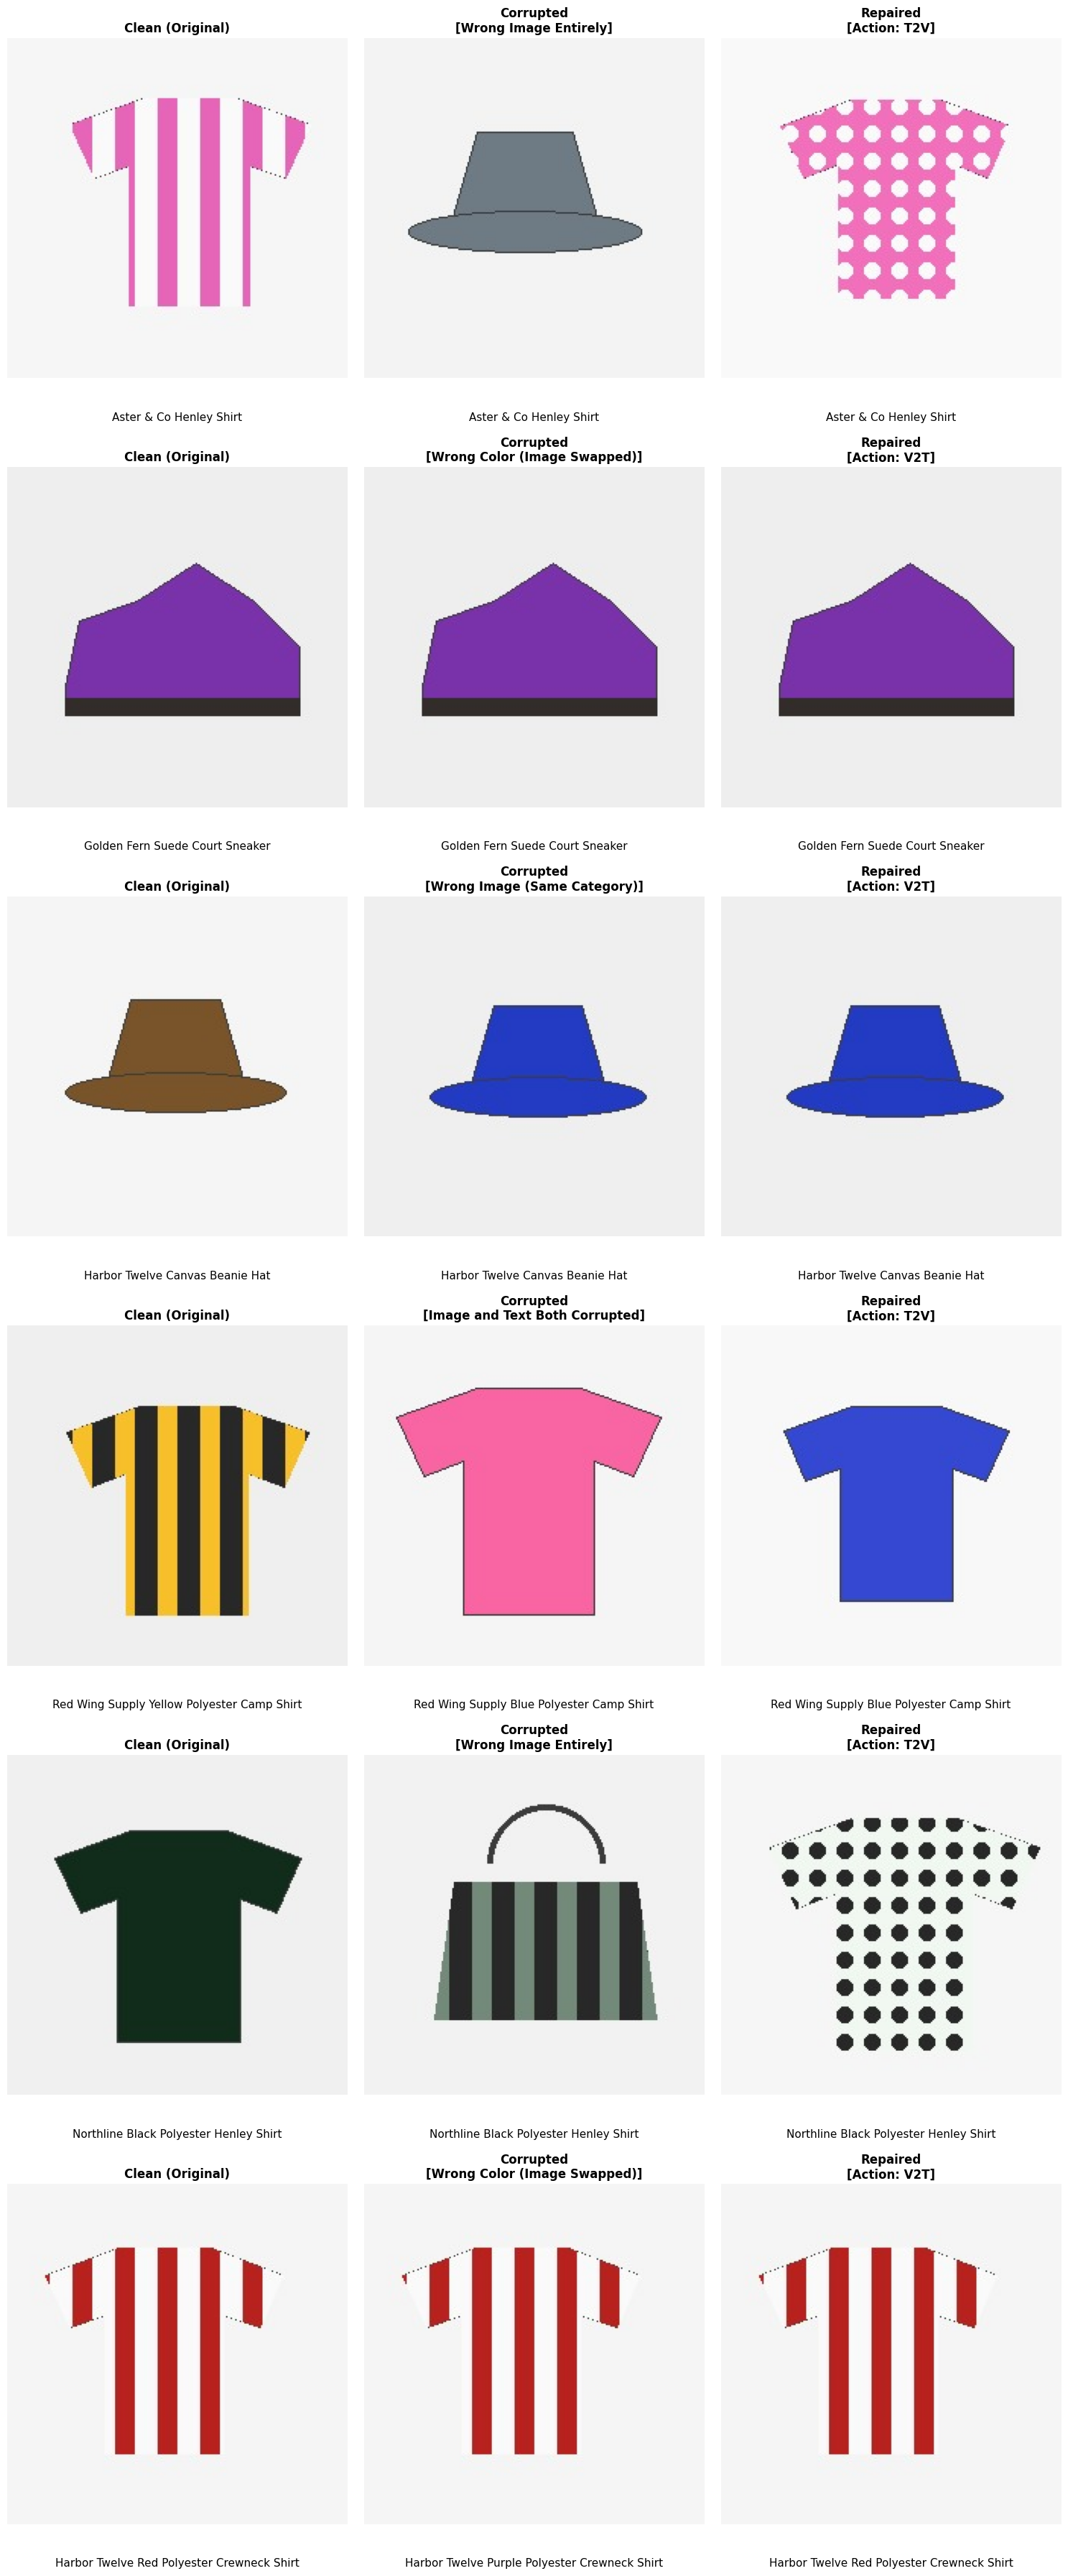

In [13]:
# Visual Inspection: See the Clean -> Corrupted -> Repaired progression
from tiger.viz import plot_repair_stages
plot_repair_stages(seed=7)


In [ ]:
# 🧪 Test the Generative Fallback directly
!python -m tiger.cli generate --caption "vintage leather jacket" --output "data/outputs/generated_test.jpg"

# Display the generated image
from IPython.display import Image
Image(filename="data/outputs/generated_test.jpg")
